In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Set some plotting styles for beautiful graphs
sns.set_style('whitegrid')
plt.style.use('fivethirtyeight')

# Load your cleaned datasets
try:
    df_customer = pd.read_csv('artifacts/data_preperation/customer_ready.csv')
    df_order = pd.read_csv('artifacts/data_preperation/order_master_final.csv')
    print("Files loaded successfully!")
    print("Customer data shape:", df_customer.shape)
    print("Order data shape:", df_order.shape)
except FileNotFoundError as e:
    print(e)

Files loaded successfully!
Customer data shape: (99441, 21)
Order data shape: (113425, 46)


In [5]:
df_customer.head(5)

,customer_id,total_orders,total_items,total_spent,total_freight,avg_price,avg_review_score,first_order_date,last_order_date,last_order_status,...,customer_city,customer_state,geolocation_zip_code_prefix,geolocation_lat,geolocation_lng,customer_tenure_days,days_since_last_order,avg_items_per_order,has_review,review_speed_category
0,00012a2ce6f8dcda20d059ce98491703,1,1,89.80,24.94,89.80,1.0,2017-11-14 16:08:26,2017-11-14 16:08:26,delivered,...,osasco,SP,6273.0,-23.499149,-46.767812,0,337,1.0,1,Normal
1,000161a058600d5901f007fab4c27140,1,1,54.90,12.51,54.90,4.0,2017-07-16 09:40:32,2017-07-16 09:40:32,delivered,...,itapecerica,MG,35550.0,-20.469287,-45.123459,0,458,1.0,1,Quick
2,0001fd6190edaaf884bcaf3d49edf079,1,1,179.99,15.43,179.99,5.0,2017-02-28 11:06:43,2017-02-28 11:06:43,delivered,...,nova venecia,ES,29830.0,-18.708188,-40.406942,0,596,1.0,1,Quick
3,0002414f95344307404f0ace7a26f1d5,1,1,149.90,29.45,149.90,5.0,2017-08-16 13:09:20,2017-08-16 13:09:20,delivered,...,mendonca,MG,39664.0,-21.770599,-43.355230,0,427,1.0,1,Quick
4,000379cdec625522490c315e70c7a9fb,1,1,93.00,14.01,93.00,4.0,2018-04-02 13:42:17,2018-04-02 13:42:17,delivered,...,sao paulo,SP,4841.0,-23.738796,-46.689533,0,198,1.0,1,Quick


In [6]:
df_customer.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 21 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   customer_id                  99441 non-null  object 
 1   total_orders                 99441 non-null  int64  
 2   total_items                  99441 non-null  int64  
 3   total_spent                  99441 non-null  float64
 4   total_freight                99441 non-null  float64
 5   avg_price                    99441 non-null  float64
 6   avg_review_score             99441 non-null  float64
 7   first_order_date             99441 non-null  object 
 8   last_order_date              99441 non-null  object 
 9   last_order_status            99441 non-null  object 
 10  customer_zip_code_prefix     99441 non-null  int64  
 11  customer_city                99441 non-null  object 
 12  customer_state               99441 non-null  object 
 13  geolocation_zip_

In [7]:
df_order.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 113425 entries, 0 to 113424
Data columns (total 46 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   order_id                       113425 non-null  object 
 1   order_item_id                  112650 non-null  float64
 2   product_id                     112650 non-null  object 
 3   seller_id                      112650 non-null  object 
 4   shipping_limit_date            112650 non-null  object 
 5   price                          112650 non-null  float64
 6   freight_value                  112650 non-null  float64
 7   customer_id                    113425 non-null  object 
 8   order_status                   113425 non-null  object 
 9   order_purchase_timestamp       113425 non-null  object 
 10  order_approved_at              113425 non-null  object 
 11  order_delivered_carrier_date   113425 non-null  object 
 12  order_delivered_customer_date 

In [8]:
# --- Fix Date Columns ---
# Convert object columns to datetime format
print("Converting date columns to datetime...")

# For customer data
date_cols_customer = ['first_order_date', 'last_order_date']
for col in date_cols_customer:
    df_customer[col] = pd.to_datetime(df_customer[col])

# For order data
date_cols_order = [
    'shipping_limit_date', 'order_purchase_timestamp', 
    'order_approved_at', 'order_delivered_carrier_date',
    'order_delivered_customer_date', 'order_estimated_delivery_date'
]
for col in date_cols_order:
    df_order[col] = pd.to_datetime(df_order[col])

print("Date conversion complete!")
df_customer.info()

Converting date columns to datetime...
Date conversion complete!
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 21 columns):
 #   Column                       Non-Null Count  Dtype         
---  ------                       --------------  -----         
 0   customer_id                  99441 non-null  object        
 1   total_orders                 99441 non-null  int64         
 2   total_items                  99441 non-null  int64         
 3   total_spent                  99441 non-null  float64       
 4   total_freight                99441 non-null  float64       
 5   avg_price                    99441 non-null  float64       
 6   avg_review_score             99441 non-null  float64       
 7   first_order_date             99441 non-null  datetime64[ns]
 8   last_order_date              99441 non-null  datetime64[ns]
 9   last_order_status            99441 non-null  object        
 10  customer_zip_code_prefix     99441 non-nu

In [14]:
df_customer.to_csv('artifacts/data_preperation/customer_ready.csv', index=False)

In [9]:
df_order.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 113425 entries, 0 to 113424
Data columns (total 46 columns):
 #   Column                         Non-Null Count   Dtype         
---  ------                         --------------   -----         
 0   order_id                       113425 non-null  object        
 1   order_item_id                  112650 non-null  float64       
 2   product_id                     112650 non-null  object        
 3   seller_id                      112650 non-null  object        
 4   shipping_limit_date            112650 non-null  datetime64[ns]
 5   price                          112650 non-null  float64       
 6   freight_value                  112650 non-null  float64       
 7   customer_id                    113425 non-null  object        
 8   order_status                   113425 non-null  object        
 9   order_purchase_timestamp       113425 non-null  datetime64[ns]
 10  order_approved_at              113425 non-null  datetime64[ns]
 11  

In [15]:
df_order.to_csv('artifacts/data_preperation/order_master_final.csv', index=False)

<Axes: xlabel='customer_state'>

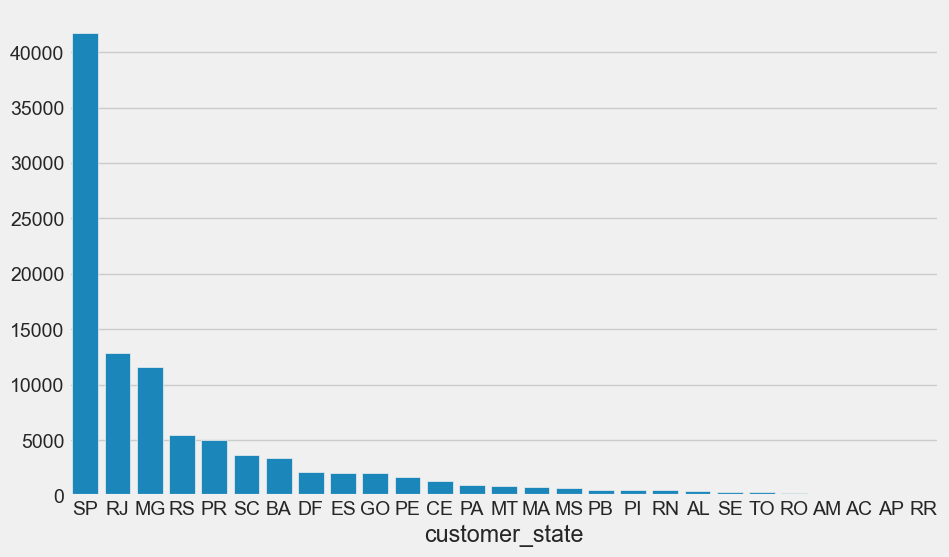

In [ ]:
plt.figure(figsize=(10, 6))
sns.barplot(x=df_customer["customer_state"].value_counts().index, y=df_customer["customer_state"].value_counts().values,)

C:\Users\Vansh\AppData\Local\Temp\ipykernel_33136\57735347.py:7: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_sales = df_order_time['price'].resample('M').sum()


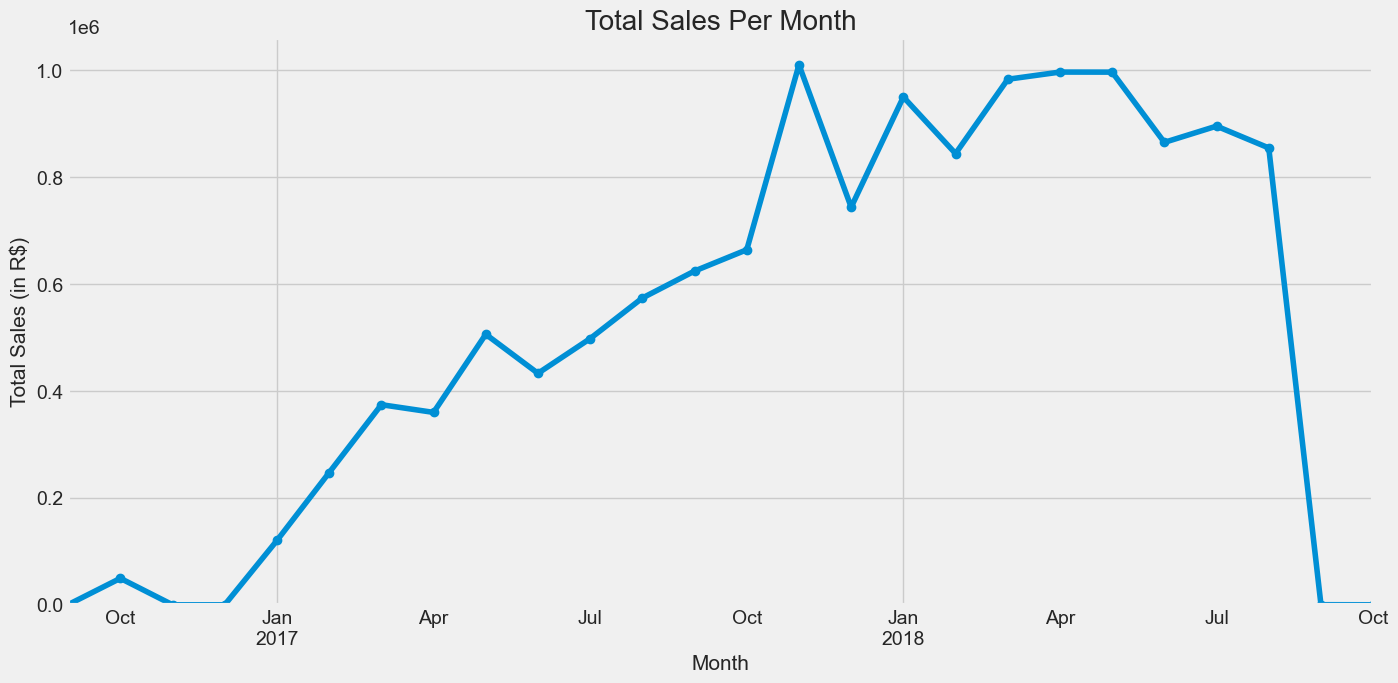

In [13]:
# --- Sales Trend Over Time ---

# We need to set the order_purchase_timestamp as the index to work with time-series data
df_order_time = df_order.set_index('order_purchase_timestamp')

# Resample the data by month ('M') and sum the price for each month
monthly_sales = df_order_time['price'].resample('M').sum()

# Create the plot
plt.figure(figsize=(15, 7))
monthly_sales.plot(kind='line', marker='o')

# Add titles and labels
plt.title('Total Sales Per Month', fontsize=20)
plt.xlabel('Month', fontsize=15)
plt.ylabel('Total Sales (in R$)', fontsize=15)
plt.ylim(0) # Start the y-axis from 0

# Show the plot
plt.show()